<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202506_DOE_DBCA_FORM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos 2025**
## **TEMA 1: Diseños en Bloques Completamente aleatorizados DBCA**



<a name="inicio"></a>


## **1.** [Librerias básicas](#T1)
## **2.** [Ejemplo de un Diseños en Bloques Completos al Azar - DBCA](#T2)

## **3.** [El DataFrame de los datos](#T3)

## **4.** [Analisis descriptivo de la variable](#T4)

## **5.** [Acediendo a algunos atributos del DataFrame](#T5)

## **6.** [BoxPlot para DBCA](#T6)

## **7.** [Análisis de Varianza - Anova](#T7)


## **8.** [Comparaciones Múltiples](#T8)

## **9.** [Supuesto del Modelo - Normalidad](#T9)


## **10.** [Homocedasticidad](#T10)


## **11.** [Independencia - _`durbin_watson`  y `Ljung-Box`_](#T11)



[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Librerías Básicas**

In [ ]:
# @title **Librerias de Python**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Ejemplo de un Diseños en Bloques Completos al Azar - DBCA**

## **A. Problema de aplicación: Control de Temperatura en Silos de Leche**

+ _En una empresa se tienen varios silos para almacenar leche (tanques de 10,000 litros).  Un aspecto crítico para que se conserve la leche es la **temperatura de almacenamiento**._  

+ _Se sospecha que en algunos silos hay problemas, por ello durante cinco días se decide registrar la temperatura a cierta hora crítica.  
La temperatura de un día a otro puede ser una fuente de variabilidad que podría impactar la variabilidad total._

## **B. Datos registrados (Temperatura en °C)**

| SILOS | Lunes | Martes | Miércoles | Jueves | Viernes |
|-------|-------|--------|-----------|--------|---------|
| A     | 3.0   | 2.5    | 2.0       | 3.0    | 2.0     |
| B     | 4.0   | 3.0    | 2.0       | 3.5    | 3.5     |
| C     | 4.5   | 4.0    | 3.5       | 5.5    | 5.0     |
| D     | 2.5   | 2.0    | 3.0       | 3.0    | 2.5     |
| E     | 3.5   | 4.0    | 3.5       | 3.0    | 3.0     |


# **Hipótesis Nula**

La hipótesis nula para este caso se plantea en términos de igualdad de las medias de temperatura entre los silos.

En notación estadística:

$$
H_{0}: \mu_A = \mu_B = \mu_C = \mu_D = \mu_E
$$

**En palabras:**
La hipótesis nula establece que **no existen diferencias significativas en la temperatura promedio de almacenamiento entre los diferentes silos**; es decir, todos los silos mantienen la misma temperatura en promedio.

¿Quieres que también te formule la **hipótesis alternativa** y la relación con el ANOVA para contrastarla?


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. El DataFrame de los datos**

In [ ]:
#@title **A. El DataFrame de los datos de temperatura de los silos**

data = {
    'SILOS': ['A', 'A', 'A', 'A', 'A',
              'B', 'B', 'B', 'B', 'B',
              'C', 'C', 'C', 'C', 'C',
              'D', 'D', 'D', 'D', 'D',
              'E', 'E', 'E', 'E', 'E'],
    'DIA': ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'] * 5,
    'TEMPERATURA': [3.0, 2.5, 2.0, 3.0, 2.0,
                    4.0, 3.0, 2.0, 3.5, 3.5,
                    4.5, 4.0, 3.5, 5.5, 5.0,
                    2.5, 2.0, 3.0, 3.0, 2.5,
                    3.5, 4.0, 3.5, 3.0, 3.0]
}

df_silos = pd.DataFrame(data)
display(df_silos)

,SILOS,DIA,TEMPERATURA
0,A,Lunes,3.0
1,A,Martes,2.5
2,A,Miércoles,2.0
3,A,Jueves,3.0
4,A,Viernes,2.0
5,B,Lunes,4.0
6,B,Martes,3.0
7,B,Miércoles,2.0
8,B,Jueves,3.5
9,B,Viernes,3.5


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Analisis descriptivo de la variable**

In [ ]:
# **Analisis descriptivo de la variable**
df_silos.describe()


,TEMPERATURA
count,25.000000
mean,3.240000
std,0.914239
min,2.000000
25%,2.500000
50%,3.000000
75%,3.500000
max,5.500000


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Acediendo a algunos atributos del DataFrame**

In [ ]:
#@title **a Nombre de las columnas**
df_silos.columns

Index(['SILOS', 'DIA', 'TEMPERATURA'], dtype='object')

[⬆️ Volver al inicio](#inicio)

In [ ]:
#@title **b Tipo de variables**
df_silos.dtypes

,0
SILOS,object
DIA,object
TEMPERATURA,float64


In [ ]:
df_silos.columns

Index(['SILOS', 'DIA', 'TEMPERATURA'], dtype='object')

In [ ]:
#@title **c. Contar las observaciones de una de las variables**
df_silos["DIA"].value_counts()

,count
DIA,
Lunes,5
Martes,5
Miércoles,5
Jueves,5
Viernes,5


In [ ]:
#@title **d. Contar las observaciones**
df_silos["TEMPERATURA"].value_counts()

,count
TEMPERATURA,
3.0,7
3.5,5
2.0,4
2.5,3
4.0,3
4.5,1
5.5,1
5.0,1


In [ ]:
#@title **e. Contar las observaciones**
df_silos["SILOS"].value_counts()

,count
SILOS,
A,5
B,5
C,5
D,5
E,5


In [ ]:
df_silos

,SILOS,DIA,TEMPERATURA
0,A,Lunes,3.0
1,A,Martes,2.5
2,A,Miércoles,2.0
3,A,Jueves,3.0
4,A,Viernes,2.0
5,B,Lunes,4.0
6,B,Martes,3.0
7,B,Miércoles,2.0
8,B,Jueves,3.5
9,B,Viernes,3.5


In [ ]:
#@title **f. Contar las observaciones**
df_silos[["SILOS","DIA"]].describe()

,SILOS,DIA
count,25,25
unique,5,5
top,A,Lunes
freq,5,5


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. BoxPlot para DBCA**

<Axes: title={'center': 'Temperatura vs Silos'}, xlabel='SILOS', ylabel='TEMPERATURA'>

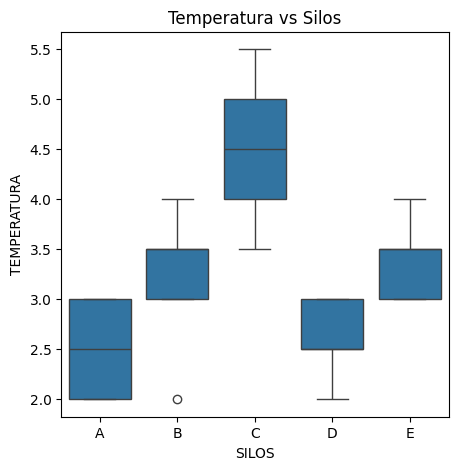

In [ ]:
#@title **A. BoxPlot para DBCA: Temperatura vs Silos**
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title('Temperatura vs Silos')
sns.boxplot(x="SILOS", y='TEMPERATURA', data=df_silos, ax=ax)

/tmp/ipython-input-1254511636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DIA", y='TEMPERATURA', data=df_silos, ax=ax, palette='viridis') # Added palette


<Axes: title={'center': 'Temperatura vs Dia'}, xlabel='DIA', ylabel='TEMPERATURA'>

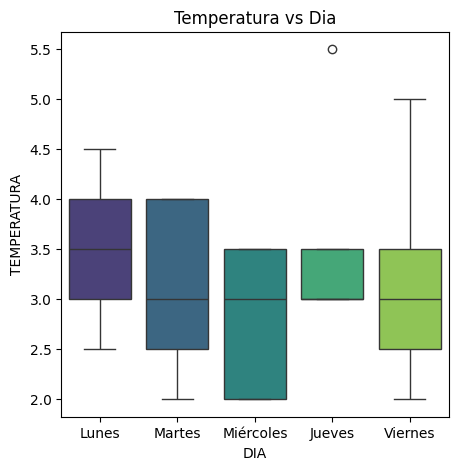

In [ ]:
#@title **B. BoxPlot para DBCA: Temperatura vs Dia**
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title('Temperatura vs Dia')
sns.boxplot(x="DIA", y='TEMPERATURA', data=df_silos, ax=ax, palette='viridis') # Added palette

/tmp/ipython-input-2247520159.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="SILOS", y='TEMPERATURA', data=df_silos, ax=axes[0], palette='viridis')
/tmp/ipython-input-2247520159.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DIA", y='TEMPERATURA', data=df_silos, ax=axes[1], palette='plasma')


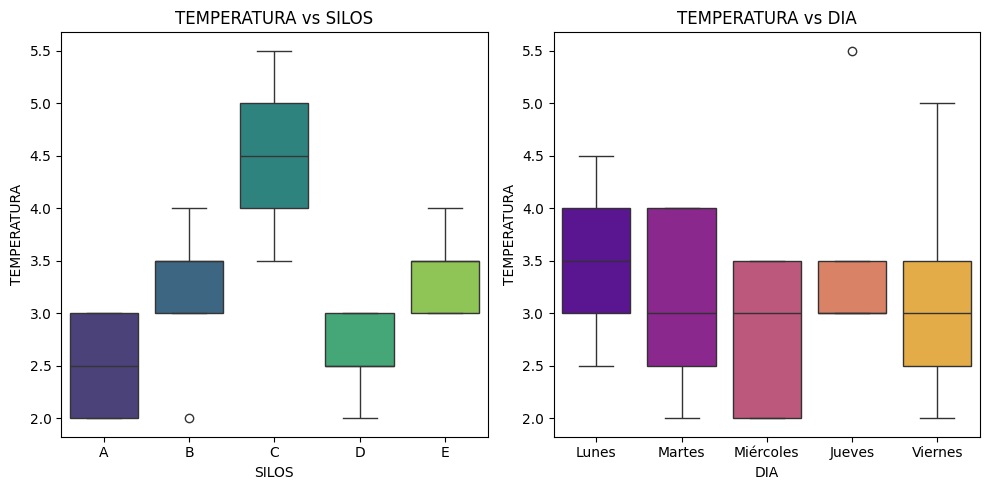

In [ ]:
# @title **C. Boxplot en un solo plano con colores diversos**
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(x="SILOS", y='TEMPERATURA', data=df_silos, ax=axes[0], palette='viridis')
axes[0].set_title('TEMPERATURA vs SILOS')

sns.boxplot(x="DIA", y='TEMPERATURA', data=df_silos, ax=axes[1], palette='plasma')
axes[1].set_title('TEMPERATURA vs DIA')

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Análisis de Varianza - Anova**

In [ ]:
df_silos.columns

Index(['SILOS', 'DIA', 'TEMPERATURA'], dtype='object')

In [ ]:
#@title **A. Análisis de Varianza Tipo I**
modelo_df_silos = ols("TEMPERATURA ~ SILOS + DIA", data = df_silos).fit()
anova_result2 = sm.stats.anova_lm(modelo_df_silos, typ=1)
print (anova_result2)

            df  sum_sq  mean_sq          F    PR(>F)
SILOS      4.0   12.86  3.21500  10.007782  0.000297
DIA        4.0    2.06  0.51500   1.603113  0.221868
Residual  16.0    5.14  0.32125        NaN       NaN


+ Según el Anova, la Hipotesis Nula
$$
H_{0}: \mu_A = \mu_B = \mu_C = \mu_D = \mu_E
$$

+ Se rechaza, esdecir, hay evidencia estadística muy significativa en las muestras para afirmar que almenos un par de Silos presentan temeparaturas medias diferentes


In [ ]:
anova_result2.T

,SILOS,DIA,Residual
df,4.000000,4.000000,16.00000
sum_sq,12.860000,2.060000,5.14000
mean_sq,3.215000,0.515000,0.32125
F,10.007782,1.603113,NaN
PR(>F),0.000297,0.221868,NaN


In [ ]:
#@title **B. Análisis de Varianza para el modelo**
print(modelo_df_silos.summary())

                            OLS Regression Results                            
Dep. Variable:            TEMPERATURA   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     5.805
Date:                Fri, 12 Sep 2025   Prob (F-statistic):            0.00142
Time:                        20:33:22   Log-Likelihood:                -15.701
No. Observations:                  25   AIC:                             49.40
Df Residuals:                      16   BIC:                             60.37
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.8600      0.340  

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Comparaciones Múltiples**

group1,group2,meandiff,p-adj,lower,upper,reject
A,B,0.7,0.3773,-0.4355,1.8355,False
A,C,2.0,0.0003,0.8645,3.1355,True
A,D,0.1,0.9988,-1.0355,1.2355,False
A,E,0.9,0.1642,-0.2355,2.0355,False
B,C,1.3,0.02,0.1645,2.4355,True
B,D,-0.6,0.5254,-1.7355,0.5355,False
B,E,0.2,0.9835,-0.9355,1.3355,False
C,D,-1.9,0.0006,-3.0355,-0.7645,True
C,E,-1.1,0.0605,-2.2355,0.0355,False
D,E,0.8,0.2552,-0.3355,1.9355,False


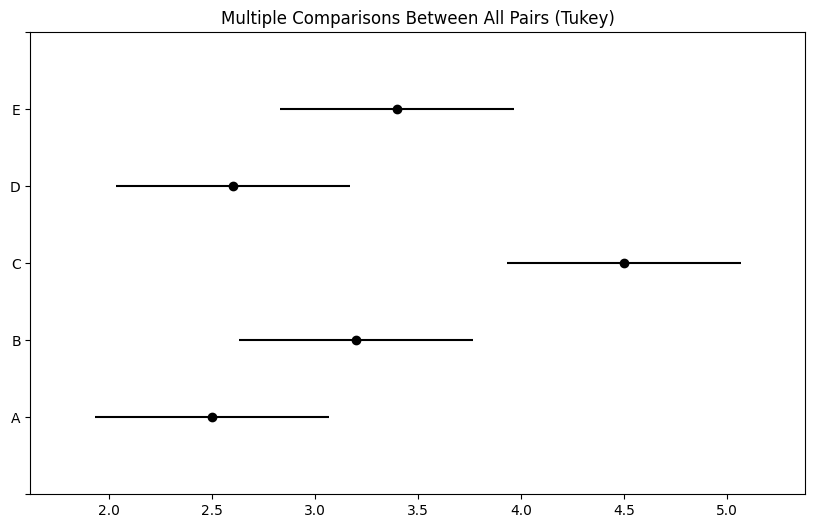

In [ ]:
# @title **A. Comparaciones Múltiples para SILOS**
tukey = pairwise_tukeyhsd(endog=df_silos["TEMPERATURA"],     # Data
                          groups=df_silos["SILOS"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
plt.vlines(x=tukey.meandiffs.mean(),ymin=-0.5,ymax=len(tukey.groups), color="red")
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Jueves,Lunes,-0.1,0.9998,-1.8954,1.6954,False
Jueves,Martes,-0.5,0.917,-2.2954,1.2954,False
Jueves,Miércoles,-0.8,0.6746,-2.5954,0.9954,False
Jueves,Viernes,-0.4,0.9613,-2.1954,1.3954,False
Lunes,Martes,-0.4,0.9613,-2.1954,1.3954,False
Lunes,Miércoles,-0.7,0.7696,-2.4954,1.0954,False
Lunes,Viernes,-0.3,0.9864,-2.0954,1.4954,False
Martes,Miércoles,-0.3,0.9864,-2.0954,1.4954,False
Martes,Viernes,0.1,0.9998,-1.6954,1.8954,False
Miércoles,Viernes,0.4,0.9613,-1.3954,2.1954,False


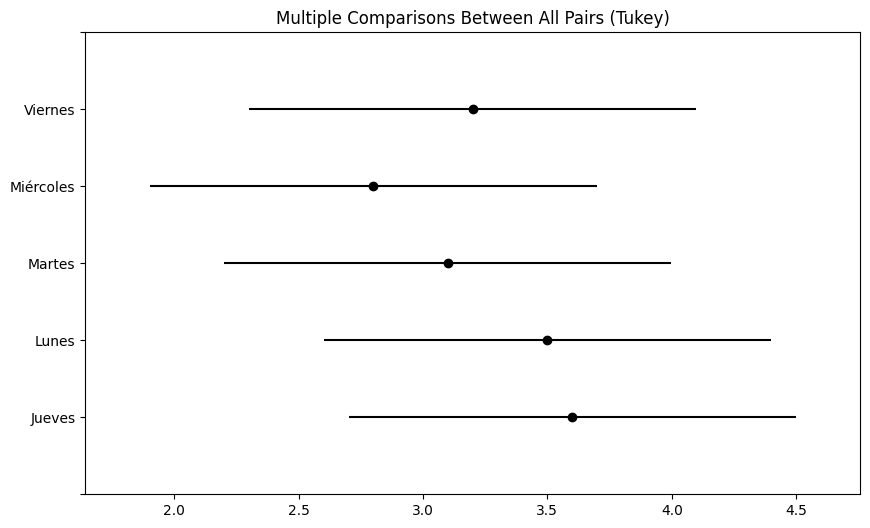

In [ ]:
# @title **B. Comparaciones Múltiples para DIA**
tukey = pairwise_tukeyhsd(endog=df_silos["TEMPERATURA"],     # Data
                          groups=df_silos["DIA"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
plt.vlines(x=tukey.meandiffs.mean(),ymin=-0.5,ymax=len(tukey.groups), color="red")
tukey.summary()

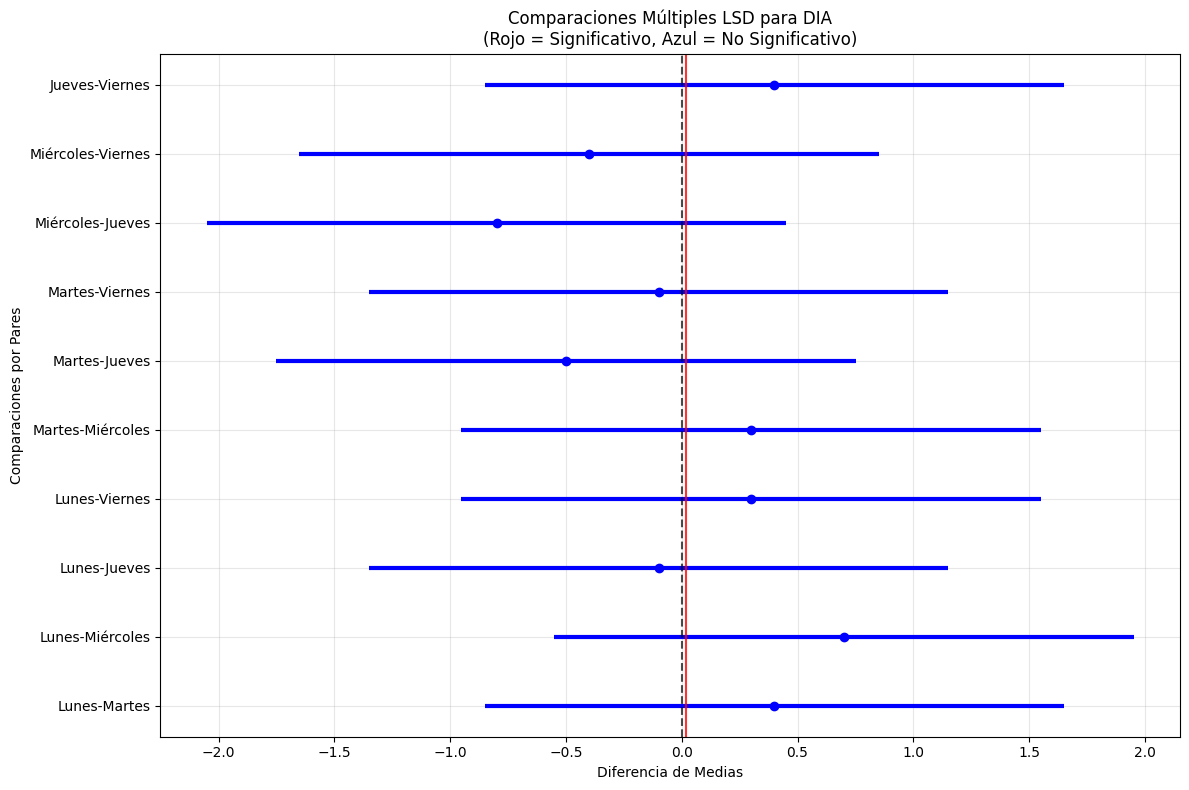

Resumen de Comparaciones LSD:
MSE: 0.9000
Grados de libertad error: 20
Valor crítico t: 2.0860

Lunes vs Martes: diff=0.4000, p=0.5126 NS
Lunes vs Miércoles: diff=0.7000, p=0.2571 NS
Lunes vs Jueves: diff=-0.1000, p=0.8693 NS
Lunes vs Viernes: diff=0.3000, p=0.6225 NS
Martes vs Miércoles: diff=0.3000, p=0.6225 NS
Martes vs Jueves: diff=-0.5000, p=0.4145 NS
Martes vs Viernes: diff=-0.1000, p=0.8693 NS
Miércoles vs Jueves: diff=-0.8000, p=0.1974 NS
Miércoles vs Viernes: diff=-0.4000, p=0.5126 NS
Jueves vs Viernes: diff=0.4000, p=0.5126 NS

Tabla Resumen LSD:
   group1    group2  meandiff    p-adj     lower    upper  reject
    Lunes    Martes       0.4 0.512603 -0.851578 1.651578   False
    Lunes Miércoles       0.7 0.257068 -0.551578 1.951578   False
    Lunes    Jueves      -0.1 0.869306 -1.351578 1.151578   False
    Lunes   Viernes       0.3 0.622532 -0.951578 1.551578   False
   Martes Miércoles       0.3 0.622532 -0.951578 1.551578   False
   Martes    Jueves      -0.5 0.414499 -1

In [ ]:
# @title **B. Comparaciones Múltiples para DIA - LSD**
from statsmodels.stats.libqsturng import psturng
import matplotlib.pyplot as plt
import pandas as pd

# Calcular estadísticas necesarias para LSD
groups = df_silos["DIA"]
unique_groups = groups.unique()
k = len(unique_groups)
n_total = len(df_silos["TEMPERATURA"])

# Calcular ANOVA simple para obtener MSE
from scipy.stats import f_oneway
anova_groups = [df_silos["TEMPERATURA"][groups == group] for group in unique_groups]
f_stat, p_value = f_oneway(*anova_groups)

# Calcular MSE manualmente
ss_within = sum([sum((group - group.mean())**2) for group in anova_groups])
df_within = n_total - k
mse = ss_within / df_within

# Valor crítico t para LSD
t_critical = stats.t.ppf(1 - 0.05/2, df_within)

# Realizar comparaciones por pares LSD
results = []
for i in range(k):
    for j in range(i+1, k):
        group1 = unique_groups[i]
        group2 = unique_groups[j]

        mean1 = df_silos[groups == group1]["TEMPERATURA"].mean()
        mean2 = df_silos[groups == group2]["TEMPERATURA"].mean()
        n1 = sum(groups == group1)
        n2 = sum(groups == group2)

        # Calcular diferencia de medias y error estándar
        mean_diff = mean1 - mean2
        se_diff = np.sqrt(mse * (1/n1 + 1/n2))

        # Estadístico t y valor p
        t_stat = mean_diff / se_diff
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_within))

        # Calcular LSD para este par
        lsd = t_critical * se_diff

        # Determinar significancia
        significant = abs(mean_diff) > lsd

        results.append({
            'group1': group1,
            'group2': group2,
            'meandiff': mean_diff,
            'p-adj': p_val,
            'lower': mean_diff - lsd,
            'upper': mean_diff + lsd,
            'reject': significant
        })

# Crear DataFrame con resultados
results_df = pd.DataFrame(results)

# Plot de intervalos de confianza LSD
plt.figure(figsize=(12, 8))
colors = ['red' if row['reject'] else 'blue' for _, row in results_df.iterrows()]

for idx, row in enumerate(results_df.iterrows()):
    _, data = row
    plt.hlines(y=idx, xmin=data['lower'], xmax=data['upper'],
               color=colors[idx], linewidth=3)
    plt.plot(data['meandiff'], idx, 'o', color=colors[idx])

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=results_df['meandiff'].mean(), color='red', linestyle='-', alpha=0.8)
plt.yticks(range(len(results_df)),
           [f"{row['group1']}-{row['group2']}" for _, row in results_df.iterrows()])
plt.xlabel('Diferencia de Medias')
plt.ylabel('Comparaciones por Pares')
plt.title('Comparaciones Múltiples LSD para DIA\n(Rojo = Significativo, Azul = No Significativo)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen de resultados
print("Resumen de Comparaciones LSD:")
print("=" * 60)
print(f"MSE: {mse:.4f}")
print(f"Grados de libertad error: {df_within}")
print(f"Valor crítico t: {t_critical:.4f}")
print()

for _, row in results_df.iterrows():
    sign = "***" if row['reject'] else "NS"
    print(f"{row['group1']} vs {row['group2']}: "
          f"diff={row['meandiff']:.4f}, p={row['p-adj']:.4f} {sign}")

# Tabla resumen similar a Tukey
summary_df = results_df[['group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject']]
print("\n" + "=" * 60)
print("Tabla Resumen LSD:")
print("=" * 60)
print(summary_df.to_string(index=False))

CÁLCULO DEL LSD GLOBAL:
MSE: 0.9000
Grados de libertad error: 20
Valor crítico t (α=0.05, df=20): 2.0860
Tamaño de muestra promedio (n): 5.00
LSD GLOBAL: 1.2516



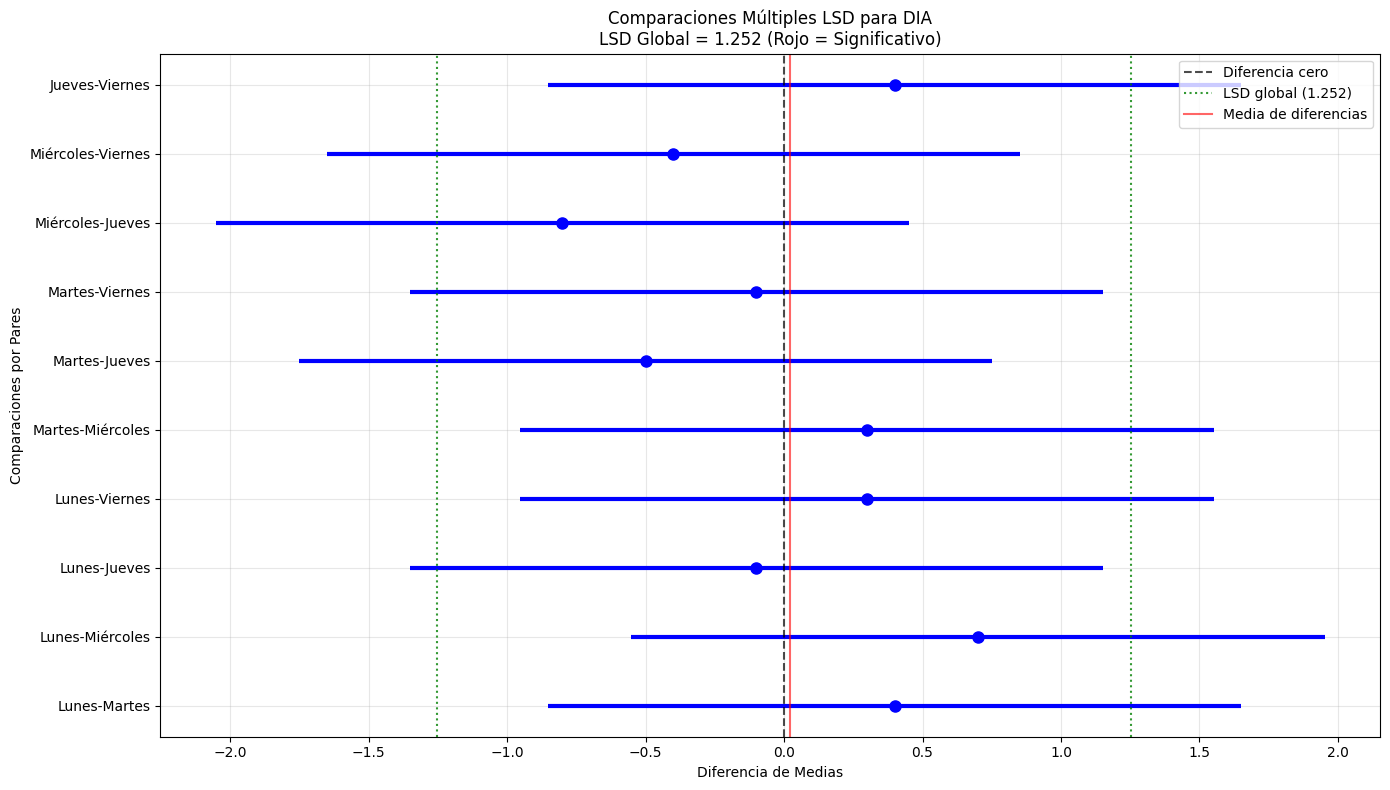

RESUMEN DE COMPARACIONES LSD:
LSD Global de referencia: 1.2516
Valor crítico t: 2.0860
MSE: 0.9000
Grados de libertad error: 20

COMPARACIONES POR PARES:
--------------------------------------------------------------------------------
Lunes vs Martes: diff=0.4000, p=0.5126 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Lunes vs Miércoles: diff=0.7000, p=0.2571 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Lunes vs Jueves: diff=-0.1000, p=0.8693 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Lunes vs Viernes: diff=0.3000, p=0.6225 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Martes vs Miércoles: diff=0.3000, p=0.6225 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Martes vs Jueves: diff=-0.5000, p=0.4145 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Martes vs Viernes: diff=-0.1000, p=0.8693 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Miércoles vs Jueves: diff=-0.8000, p=0.1974 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Miércoles vs Viernes: diff=-0.4000, p=0.5126 (LSD_par=1.2516 NS, LSD_global=1.2516 NS)
Jueves vs V

In [ ]:
# @title **B. Comparaciones Múltiples para DIA - LSD**
from statsmodels.stats.libqsturng import psturng
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats

# Calcular estadísticas necesarias para LSD
groups = df_silos["DIA"]
unique_groups = groups.unique()
k = len(unique_groups)
n_total = len(df_silos["TEMPERATURA"])

# Calcular ANOVA simple para obtener MSE
from scipy.stats import f_oneway
anova_groups = [df_silos["TEMPERATURA"][groups == group] for group in unique_groups]
f_stat, p_value = f_oneway(*anova_groups)

# Calcular MSE manualmente
ss_within = sum([sum((group - group.mean())**2) for group in anova_groups])
df_within = n_total - k
mse = ss_within / df_within

# Valor crítico t para LSD
t_critical = stats.t.ppf(1 - 0.05/2, df_within)

# =========================================================================
# CÁLCULO DEL VALOR LSD GLOBAL
# =========================================================================
# Calcular el tamaño de muestra promedio por grupo
n_values = [len(group) for group in anova_groups]
n_promedio = np.mean(n_values)

# Calcular el LSD global (asumiendo tamaños de muestra balanceados)
lsd_global = t_critical * np.sqrt(2 * mse / n_promedio)

print("CÁLCULO DEL LSD GLOBAL:")
print("=" * 40)
print(f"MSE: {mse:.4f}")
print(f"Grados de libertad error: {df_within}")
print(f"Valor crítico t (α=0.05, df={df_within}): {t_critical:.4f}")
print(f"Tamaño de muestra promedio (n): {n_promedio:.2f}")
print(f"LSD GLOBAL: {lsd_global:.4f}")
print("=" * 40)
print()

# Realizar comparaciones por pares LSD
results = []
for i in range(k):
    for j in range(i+1, k):
        group1 = unique_groups[i]
        group2 = unique_groups[j]

        mean1 = df_silos[groups == group1]["TEMPERATURA"].mean()
        mean2 = df_silos[groups == group2]["TEMPERATURA"].mean()
        n1 = sum(groups == group1)
        n2 = sum(groups == group2)

        # Calcular diferencia de medias y error estándar
        mean_diff = mean1 - mean2
        se_diff = np.sqrt(mse * (1/n1 + 1/n2))

        # Estadístico t y valor p
        t_stat = mean_diff / se_diff
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_within))

        # Calcular LSD para este par específico
        lsd_par = t_critical * se_diff

        # Determinar significancia usando ambos criterios
        significant_par = abs(mean_diff) > lsd_par
        significant_global = abs(mean_diff) > lsd_global

        results.append({
            'group1': group1,
            'group2': group2,
            'meandiff': mean_diff,
            'p-adj': p_val,
            'lower': mean_diff - lsd_par,
            'upper': mean_diff + lsd_par,
            'reject_par': significant_par,
            'reject_global': significant_global,
            'lsd_par': lsd_par,
            'lsd_global_ref': lsd_global
        })

# Crear DataFrame con resultados
results_df = pd.DataFrame(results)

# Plot de intervalos de confianza LSD
plt.figure(figsize=(14, 8))
colors = ['red' if row['reject_par'] else 'blue' for _, row in results_df.iterrows()]

for idx, row in enumerate(results_df.iterrows()):
    _, data = row
    plt.hlines(y=idx, xmin=data['lower'], xmax=data['upper'],
               color=colors[idx], linewidth=3)
    plt.plot(data['meandiff'], idx, 'o', color=colors[idx], markersize=8)

# Líneas de referencia
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Diferencia cero')
plt.axvline(x=lsd_global, color='green', linestyle=':', alpha=0.8, label=f'LSD global ({lsd_global:.3f})')
plt.axvline(x=-lsd_global, color='green', linestyle=':', alpha=0.8)
plt.axvline(x=results_df['meandiff'].mean(), color='red', linestyle='-', alpha=0.6, label='Media de diferencias')

plt.yticks(range(len(results_df)),
           [f"{row['group1']}-{row['group2']}" for _, row in results_df.iterrows()])
plt.xlabel('Diferencia de Medias')
plt.ylabel('Comparaciones por Pares')
plt.title(f'Comparaciones Múltiples LSD para DIA\nLSD Global = {lsd_global:.3f} (Rojo = Significativo)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Resumen de resultados
print("RESUMEN DE COMPARACIONES LSD:")
print("=" * 80)
print(f"LSD Global de referencia: {lsd_global:.4f}")
print(f"Valor crítico t: {t_critical:.4f}")
print(f"MSE: {mse:.4f}")
print(f"Grados de libertad error: {df_within}")
print()

print("COMPARACIONES POR PARES:")
print("-" * 80)
for _, row in results_df.iterrows():
    sign_par = "***" if row['reject_par'] else "NS"
    sign_global = "***" if row['reject_global'] else "NS"
    print(f"{row['group1']} vs {row['group2']}: "
          f"diff={row['meandiff']:.4f}, p={row['p-adj']:.4f} "
          f"(LSD_par={row['lsd_par']:.4f} {sign_par}, "
          f"LSD_global={row['lsd_global_ref']:.4f} {sign_global})")

# Tabla resumen
print("\n" + "=" * 80)
print("TABLA RESUMEN COMPLETA LSD:")
print("=" * 80)
summary_df = results_df[['group1', 'group2', 'meandiff', 'p-adj',
                        'lsd_par', 'reject_par', 'lsd_global_ref', 'reject_global']]
print(summary_df.to_string(index=False))

# Estadísticas adicionales
print("\nESTADÍSTICAS ADICIONALES:")
print("-" * 40)
print(f"Número de comparaciones significativas (LSD par): {sum(results_df['reject_par'])}/{len(results_df)}")
print(f"Número de comparaciones significativas (LSD global): {sum(results_df['reject_global'])}/{len(results_df)}")
print(f"Tamaños de muestra por grupo: {n_values}")
print(f"Tamaño promedio: {n_promedio:.2f}")

In [ ]:
df_silos.columns

Index(['SILOS', 'DIA', 'TEMPERATURA'], dtype='object')

/tmp/ipython-input-3249353408.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x="SILOS", y="TEMPERATURA", data=df_silos, ci=95, capsize=0.1, join=False)
/tmp/ipython-input-3249353408.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="SILOS", y="TEMPERATURA", data=df_silos, ci=95, capsize=0.1, join=False)


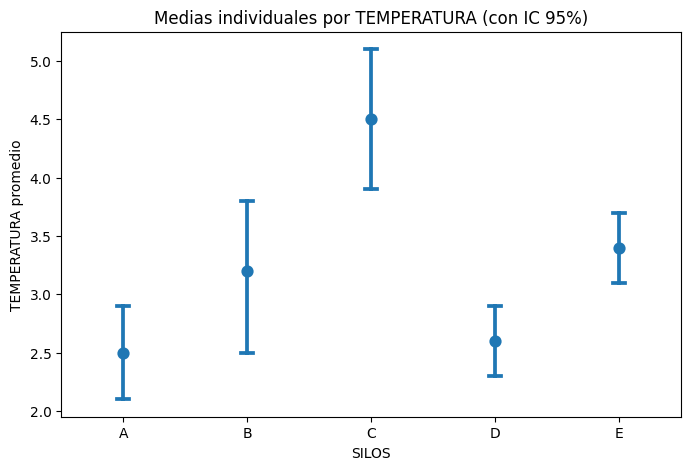

In [ ]:
# @title **B. Gráfico de medias individuales en Python**
df_silos

# Gráfico de medias con IC 95%
plt.figure(figsize=(8,5))
sns.pointplot(x="SILOS", y="TEMPERATURA", data=df_silos, ci=95, capsize=0.1, join=False)

plt.title("Medias individuales por TEMPERATURA (con IC 95%)")
plt.ylabel("TEMPERATURA promedio")
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Supuesto del Modelo - Normalidad**

In [ ]:

# @title **A. Normalidad Prueba de  Shapiro Wilks**
w, pvalue = stats.shapiro(modeloDBCA.resid)


print(f"W statistic: {w:.4f}")
print(f"p-value: {pvalue:.4f}")

W statistic: 0.9553
p-value: 0.4545


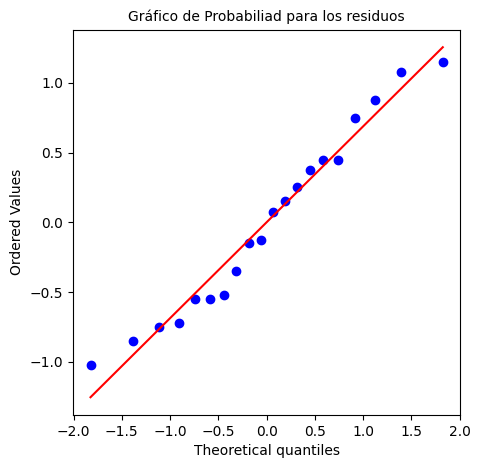

In [ ]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloDBCA.resid, plot= plt, rvalue= False)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

In [ ]:
# @title **C. Residuos del Modelo**
modeloDBCA.resid.describe()

,0
count,2.000000e+01
mean,6.217249e-16
std,6.627296e-01
min,-1.025000e+00
25%,-5.500000e-01
50%,-2.500000e-02
75%,4.500000e-01
max,1.150000e+00


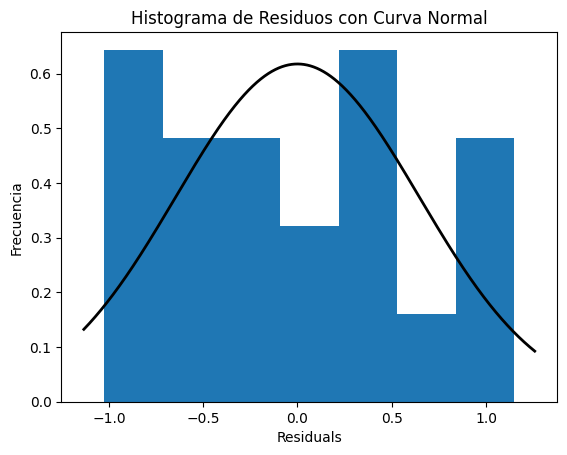

In [ ]:
# @title **D. Histograma de Residuos con curva normal teórica**
plt.hist(modeloDBCA.resid, bins=7, histtype='bar', ec='k', density=True)

# Calculate mean and standard deviation for the theoretical normal curve
mu, sigma = stats.norm.fit(modeloDBCA.resid)

# Create the theoretical normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 10000)
p = stats.norm.pdf(x, mu, sigma)

# Plot the theoretical normal curve
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel("Residuals")
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos con Curva Normal')
plt.show()

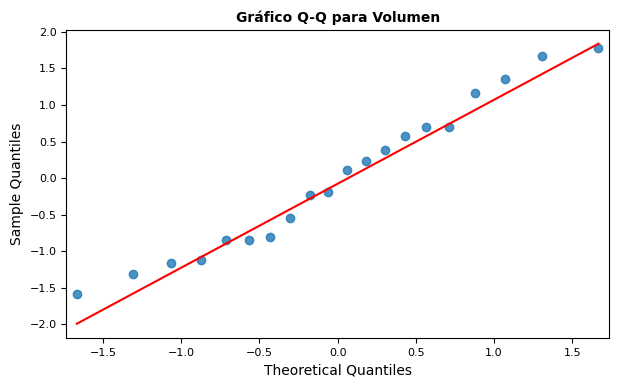

In [ ]:
# @title **E. Gráfico Q-Q**
# ==============================================================================
fig, ax = plt.subplots(figsize=(7,4))
sm.qqplot(
    Volumen,
    fit   = True,
    line  = 'q',
    alpha = 0.8,
    lw    = 5,
    ax    = ax
)
ax.set_title('Gráfico Q-Q para Volumen', fontsize = 10,
             fontweight = "bold")
ax.tick_params(labelsize = 8)

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Homocedasticidad**

In [ ]:
# @title **A. Homocedasticidad de los residuos: Usando la prueba de Levene**
L = stats.levene(DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T1'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T2'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T3'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T4'])
print("Estadístico de Levene: ", np.round(L.statistic,4))
print("Valor p: ", np.round(L.pvalue,4))

Estadístico de Levene:  1.217
Valor p:  0.3357


In [ ]:
# @title **B. Homocedasticidad de los residuos: Usando la prueba de Levene**
tratamientos = DBCA['S_Ferroso'].unique()
grupos = [DBCA.loc[DBCA['S_Ferroso'] == trt, 'V_Sanguineo'] for trt in sorted(tratamientos)]

resultado_levene = stats.levene(*grupos)

# Interpretación
print("="*60)
print("PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD")
print("="*60)
print(f"Estadístico de Levene: {resultado_levene.statistic:.4f}")
print(f"Valor p: {resultado_levene.pvalue:.4f}")

if resultado_levene.pvalue > 0.05:
    print("✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)")
else:
    print("✗ Se rechaza H0: Las varianzas NO son homogéneas (p ≤ 0.05)")
print("="*60)

PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD
Estadístico de Levene: 1.2170
Valor p: 0.3357
✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Independencia - _`durbin_watson`  y `Ljung-Box`_**

ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS
Estadístico de Durbin-Watson: 1.6084
✓ No hay evidencia de autocorrelación (los residuos son independientes)
----------------------------------------


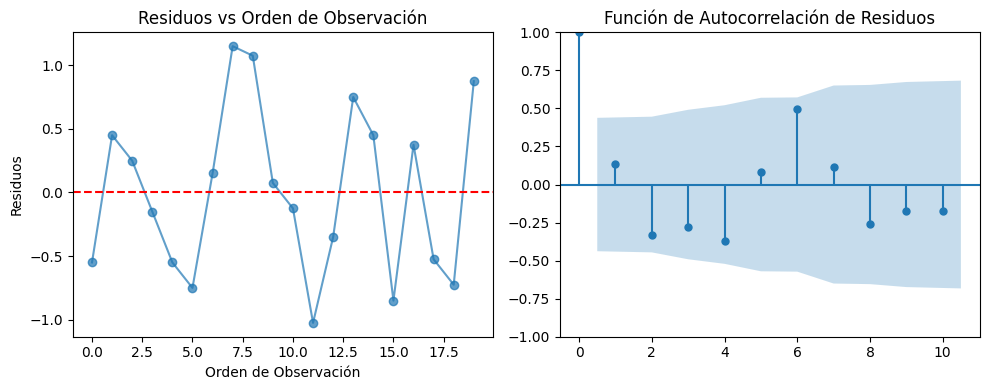


Prueba de Ljung-Box (lag 5): p-value = 0.1020
✓ No se rechaza H0: No hay autocorrelación (residuos independientes)


In [ ]:
# @title **B. Supuesto de Independencia de los residuos**

print("="*60)
print("ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS")
print("="*60)

# 1. Prueba de Durbin-Watson (para autocorrelación)
from statsmodels.stats.stattools import durbin_watson

# Asumiendo que tienes un modelo ANOVA ya ajustado
# Si no, primero ajusta el modelo:
from statsmodels.formula.api import ols

modelo = ols('V_Sanguineo ~ S_Ferroso + Pesos', data=DBCA).fit()
residuos = modelo.resid

# Prueba de Durbin-Watson
dw_test = durbin_watson(residuos)
print(f"Estadístico de Durbin-Watson: {dw_test:.4f}")

# Interpretación
if 1.5 < dw_test < 2.5:
    print("✓ No hay evidencia de autocorrelación (los residuos son independientes)")
elif dw_test <= 1.5:
    print("✗ Positiva autocorrelación detectada (los residuos no son independientes)")
else:
    print("✗ Negativa autocorrelación detectada (los residuos no son independientes)")

print("-"*40)

# 2. Gráfico de residuos vs orden de observación
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(residuos, 'o-', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Orden de Observación')
plt.xlabel('Orden de Observación')
plt.ylabel('Residuos')

# 3. Gráfico de autocorrelación
plt.subplot(1, 2, 2)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=10, alpha=0.05, ax=plt.gca())
plt.title('Función de Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

# 4. Prueba de Ljung-Box (opcional)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuos, lags=[5], return_df=True)
print(f"\nPrueba de Ljung-Box (lag 5): p-value = {lb_test['lb_pvalue'].values[0]:.4f}")

if lb_test['lb_pvalue'].values[0] > 0.05:
    print("✓ No se rechaza H0: No hay autocorrelación (residuos independientes)")
else:
    print("✗ Se rechaza H0: Hay autocorrelación (residuos no independientes)")

print("="*60)

[⬆️ Volver al inicio](#inicio)

In [ ]:
# @title **C. Comparaciones Múltiples para SILOS (LSD)**
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats

# Asegúrate de que el modelo_df_silos esté definido y ajustado (de la sección 7)
# Si no lo está, ejecuta la celda de ANOVA en la sección 7.
try:
    # Extraer el Mean Squared Error (MSE) del modelo ANOVA
    # El MSE es el Residual mean square en el summary del ANOVA tipo I
    anova_table = sm.stats.anova_lm(modelo_df_silos, typ=1)
    mse = anova_table['mean_sq']['Residual']
    df_error = anova_table['df']['Residual']

    alpha = 0.05
    t_critical = stats.t.ppf(1 - alpha/2, df_error)

    # Obtener las medias y tamaños de grupo por SILO
    group_means = df_silos.groupby('SILOS')['TEMPERATURA'].mean()
    group_counts = df_silos.groupby('SILOS').size()
    unique_silos = group_means.index

    print("Medias de Temperatura por Silo:")
    print(group_means)
    print("\n" + "="*60)
    print("Resultados de la Prueba LSD para SILOS (Manual):")
    print("="*60)

    results = []
    for i in range(len(unique_silos)):
        for j in range(i + 1, len(unique_silos)):
            silo1 = unique_silos[i]
            silo2 = unique_silos[j]

            mean1 = group_means[silo1]
            mean2 = group_means[silo2]
            n1 = group_counts[silo1]
            n2 = group_counts[silo2]

            # Calcular la diferencia de medias y el error estándar
            mean_diff = mean1 - mean2
            se_diff = np.sqrt(mse * (1/n1 + 1/n2))

            # Calcular el Intervalo de Confianza LSD
            lower_ci = mean_diff - t_critical * se_diff
            upper_ci = mean_diff + t_critical * se_diff

            # Determinar si la diferencia es significativa (intervalo no contiene 0)
            reject_h0 = (lower_ci > 0) or (upper_ci < 0)

            # Calcular el p-valor (opcional, basado en el estadístico t)
            t_stat = mean_diff / se_diff
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df_error))


            results.append({
                'group1': silo1,
                'group2': silo2,
                'meandiff': mean_diff,
                'lower': lower_ci,
                'upper': upper_ci,
                'reject_h0': reject_h0,
                'p-value': p_value
            })

    results_df = pd.DataFrame(results)
    print(results_df[['group1', 'group2', 'meandiff', 'lower', 'upper', 'reject_h0', 'p-value']].to_string(index=False))
    print("="*60)


    # Interpretación para encontrar los silos con menor temperatura
    print("\nAnálisis para identificar silos con menor temperatura:")
    print("="*70)

    # Silos ordenados por temperatura media (de menor a mayor)
    ordered_silos = group_means.sort_values()
    lowest_silo_name = ordered_silos.index[0]
    print(f"El silo con la temperatura media más baja es: {lowest_silo_name} ({ordered_silos.iloc[0]:.2f}°C)")

    # Identificar silos que NO son significativamente diferentes del silo con la menor media
    silos_not_significantly_different_from_lowest = []
    for index, row in results_df.iterrows():
        if row['reject_h0'] == False: # Si no se rechaza H0
            # Si la comparación involucra al silo con la menor media
            if row['group1'] == lowest_silo_name:
                 silos_not_significantly_different_from_lowest.append(row['group2'])
            elif row['group2'] == lowest_silo_name:
                 silos_not_significantly_different_from_lowest.append(row['group1'])

    # Eliminar duplicados y el silo más bajo de la lista
    silos_not_significantly_different_from_lowest = list(set(silos_not_significantly_different_from_lowest))
    if lowest_silo_name in silos_not_significantly_different_from_lowest:
         silos_not_significantly_different_from_lowest.remove(lowest_silo_name)

    print(f"\nSegún la prueba LSD (alpha={alpha}), el silo '{lowest_silo_name}' NO es significativamente diferente de los siguientes silos:")
    print(silos_not_significantly_different_from_lowest)

    # Conclusión sobre los silos con menor temperatura
    if not silos_not_significantly_different_from_lowest:
        print(f"\nConclusión: Según la prueba LSD, el silo '{lowest_silo_name}' presenta una temperatura media significativamente menor que *todos* los demás silos.")
        print(f"Por lo tanto, el silo con menor temperatura de almacenamiento es: {lowest_silo_name}.")
    else:
        print(f"\nConclusión: Según la prueba LSD, el grupo de silos con menor temperatura de almacenamiento (que no son significativamente diferentes entre sí) incluye a '{lowest_silo_name}' y los siguientes silos:")
        print([lowest_silo_name] + silos_not_significantly_different_from_lowest)
        print("Todos los silos en esta lista presentan temperaturas medias que no son significativamente diferentes de la temperatura más baja.")


except NameError:
    print("Error: La variable 'modelo_df_silos' no está definida.")
    print("Por favor, asegúrate de haber ejecutado la celda de Análisis de Varianza (ANOVA) en la sección 7 antes de ejecutar este código.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Medias de Temperatura por Silo:
SILOS
A    2.5
B    3.2
C    4.5
D    2.6
E    3.4
Name: TEMPERATURA, dtype: float64

Resultados de la Prueba LSD para SILOS (Manual):
group1 group2  meandiff    lower    upper  reject_h0  p-value
     A      B      -0.7 -1.45992  0.05992      False 0.068570
     A      C      -2.0 -2.75992 -1.24008       True 0.000042
     A      D      -0.1 -0.85992  0.65992      False 0.783846
     A      E      -0.9 -1.65992 -0.14008       True 0.023171
     B      C      -1.3 -2.05992 -0.54008       True 0.002268
     B      D       0.6 -0.15992  1.35992      False 0.113607
     B      E      -0.2 -0.95992  0.55992      False 0.584616
     C      D       1.9  1.14008  2.65992       True 0.000072
     C      E       1.1  0.34008  1.85992       True 0.007347
     D      E      -0.8 -1.55992 -0.04008       True 0.040285

Análisis para identificar silos con menor temperatura:
El silo con la temperatura media más baja es: A (2.50°C)

Según la prueba LSD (alpha=0.05), el 